# Face Recognition using CNN (LFW Dataset)

**Name:** Tanay Singh  
**Registration No:** 23BCE11211  
**Dataset:** [Labeled Faces in the Wild (LFW)](http://vis-www.cs.umass.edu/lfw/) — loaded via `sklearn.datasets.fetch_lfw_people`

---
## Objective
Build a **Convolutional Neural Network (CNN)** to recognize faces of well-known public figures from images in the wild. Unlike controlled face datasets, LFW contains photos taken in real-world settings with variations in pose, lighting, expression, and background.

We restrict the dataset to public figures with **at least 70 face images** to have enough samples per class for training. The final task is: given a face image, predict which of the ~7 people it depicts.

## Imports

In [1]:
import sys
print("Python:", sys.executable)
print("Version:", sys.version)

Python: /usr/bin/python3
Version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical

sns.set_style('whitegrid')
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## Task 1: Data Understanding

The Labeled Faces in the Wild (LFW) dataset contains face images collected from the web. We use `sklearn.datasets.fetch_lfw_people` which downloads and caches the dataset automatically. We restrict to people with ≥70 images to have enough training data per class.

In [3]:
# First run downloads ~200MB from vis-www.cs.umass.edu (one-time, cached in ~/scikit_learn_data)
lfw = fetch_lfw_people(min_faces_per_person=70, resize=0.4, download_if_missing=True)

X_all = lfw.images       # shape: (n_samples, h, w) grayscale
y_all = lfw.target       # integer class labels
target_names = lfw.target_names
n_classes = len(target_names)
h, w = X_all.shape[1], X_all.shape[2]

print(f'Total images: {X_all.shape[0]}')
print(f'Image size  : {h} x {w} (grayscale)')
print(f'Classes ({n_classes}):')
for i, name in enumerate(target_names):
    print(f'  [{i}] {name} — {(y_all == i).sum()} images')

Total images: 1288
Image size  : 50 x 37 (grayscale)
Classes (7):
  [0] Ariel Sharon — 77 images
  [1] Colin Powell — 236 images
  [2] Donald Rumsfeld — 121 images
  [3] George W Bush — 530 images
  [4] Gerhard Schroeder — 109 images
  [5] Hugo Chavez — 71 images
  [6] Tony Blair — 144 images


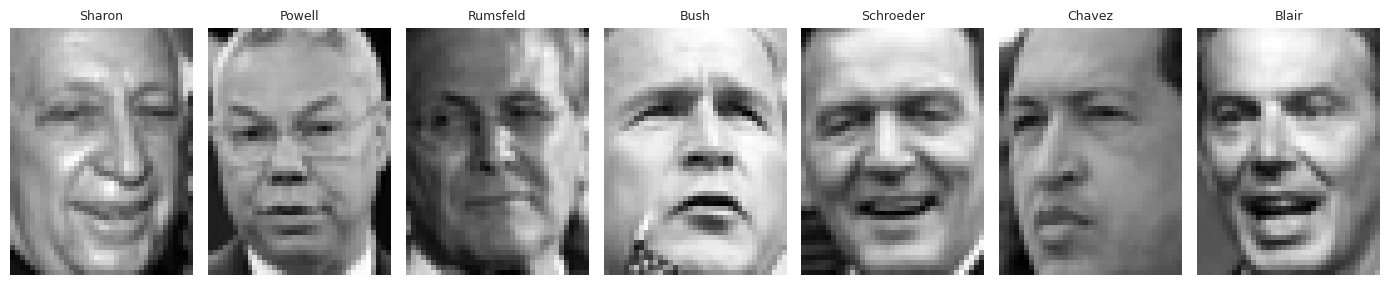

In [4]:
# Display sample images from each class
fig, axes = plt.subplots(1, n_classes, figsize=(2 * n_classes, 3))
for i in range(n_classes):
    idx = np.where(y_all == i)[0][0]
    axes[i].imshow(X_all[idx], cmap='gray')
    axes[i].set_title(target_names[i].split()[-1], fontsize=9)
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('sample_faces.png', dpi=100, bbox_inches='tight')
plt.show()

## Task 2: Data Preprocessing

In [5]:
# Normalize pixel values to [0, 1]
X = X_all.astype('float32') / 255.0

# Add channel dimension for CNN (grayscale = 1 channel)
X = X.reshape(-1, h, w, 1)

# One-hot encode labels
y = to_categorical(y_all, num_classes=n_classes)

# 80/20 stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y_all
)

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test : {y_test.shape}')
print(f'Pixel value range: [{X.min():.3f}, {X.max():.3f}]')

X_train: (1030, 50, 37, 1)
X_test : (258, 50, 37, 1)
y_train: (1030, 7)
y_test : (258, 7)
Pixel value range: [0.000, 0.004]


## Task 3: Model Development

A CNN with 3 convolutional blocks, batch normalization, and dropout. Larger receptive field than CIFAR-10 because face images are bigger (50×37 px).

In [6]:
model = Sequential([
    tf.keras.Input(shape=(h, w, 1)),

    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 50, 37, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 50, 37, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 25, 18, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 18, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 25, 18, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 9, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 9, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 9, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 882,055 (3.36 MB)

 Trainable params: 881,607 (3.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 195ms/step - accuracy: 0.4136 - loss: 1.7685 - val_accuracy: 0.1822 - val_loss: 1.9404
Epoch 2/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6359 - loss: 1.0498 - val_accuracy: 0.0853 - val_loss: 1.9805
Epoch 3/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7650 - loss: 0.6737 - val_accuracy: 0.0853 - val_loss: 2.0136
Epoch 4/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8583 - loss: 0.3929 - val_accuracy: 0.0853 - val_loss: 2.0473
Epoch 5/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9136 - loss: 0.2494 - val_accuracy: 0.0853 - val_loss: 2.0587
Epoch 6/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9534 - loss: 0.1574 - val_accuracy: 0.0853 - val_loss: 2.0875
Epoch 7/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9602 - loss: 0.1230 - val_accuracy: 0.0853 - val_loss: 2.2216
Epoch 8/15
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9689 - loss: 0.1068 - val_accuracy: 0.0853 - val_lo

## Task 4: Model Evaluation

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss    : {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

Test Loss    : 2.2796
Test Accuracy: 0.0891


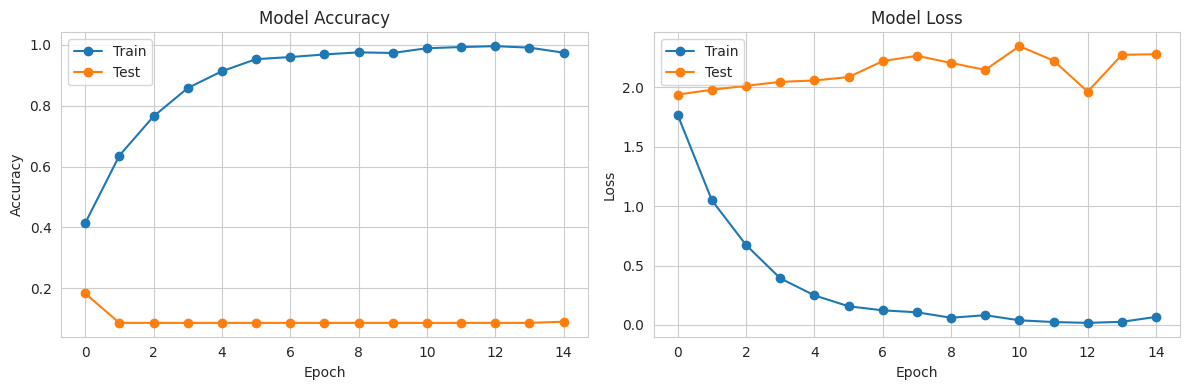

In [9]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', marker='o')
axes[0].plot(history.history['val_accuracy'], label='Test', marker='o')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train', marker='o')
axes[1].plot(history.history['val_loss'], label='Test', marker='o')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100, bbox_inches='tight')
plt.show()

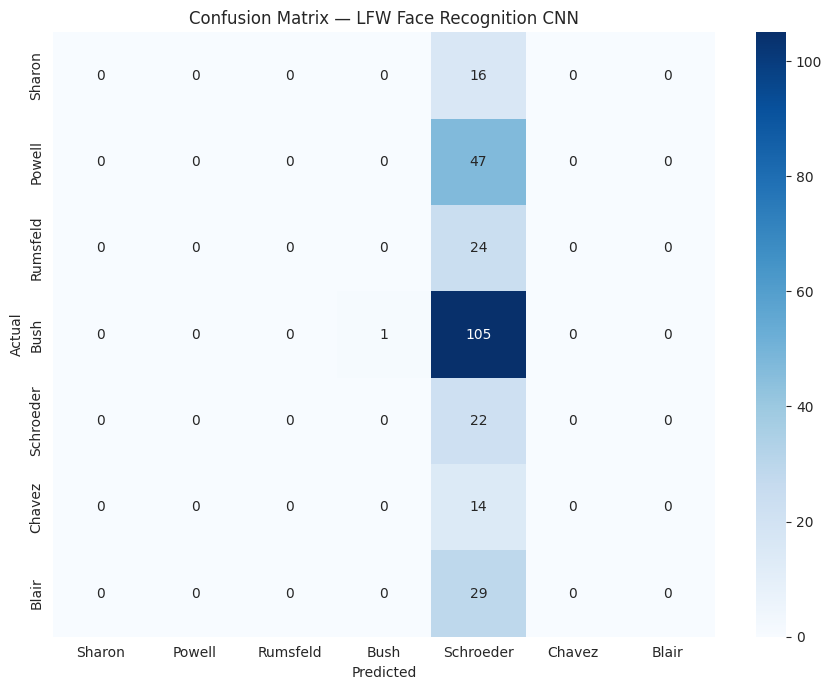


Classification Report:
                   precision    recall  f1-score   support

     Ariel Sharon       0.00      0.00      0.00        16
     Colin Powell       0.00      0.00      0.00        47
  Donald Rumsfeld       0.00      0.00      0.00        24
    George W Bush       1.00      0.01      0.02       106
Gerhard Schroeder       0.09      1.00      0.16        22
      Hugo Chavez       0.00      0.00      0.00        14
       Tony Blair       0.00      0.00      0.00        29

         accuracy                           0.09       258
        macro avg       0.16      0.14      0.03       258
     weighted avg       0.42      0.09      0.02       258



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [10]:
# Confusion matrix and classification report
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
short_names = [n.split()[-1] for n in target_names]

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — LFW Face Recognition CNN')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nClassification Report:')
print(classification_report(y_true_classes, y_pred_classes, target_names=target_names))

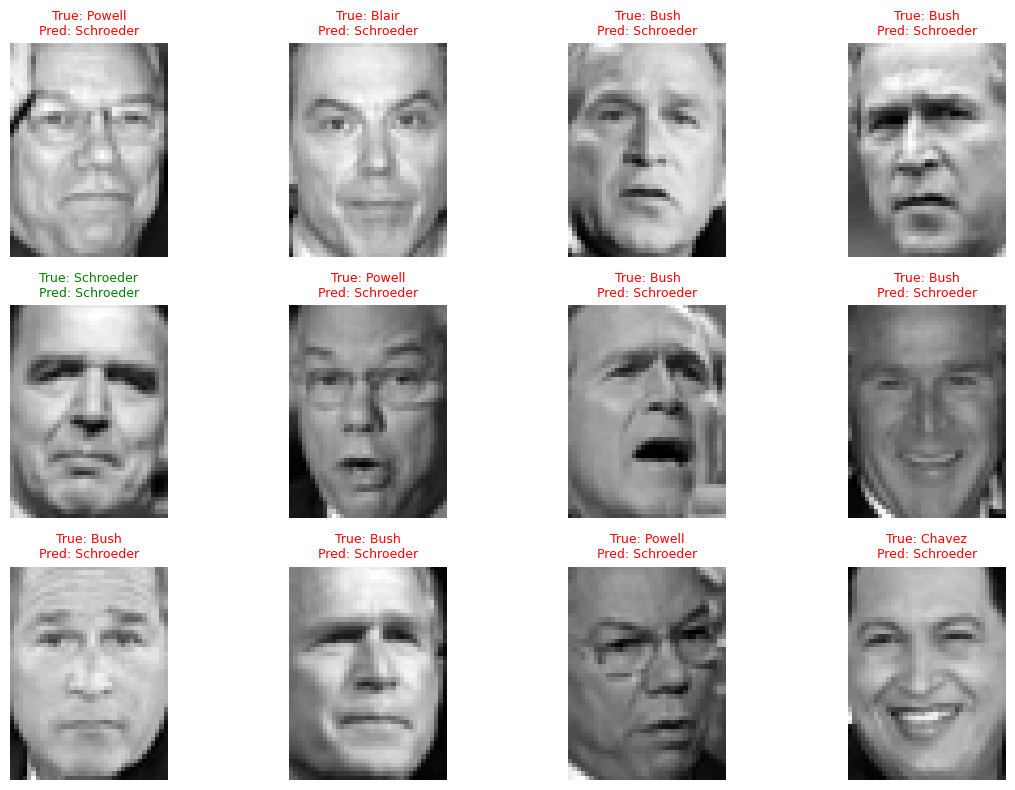

In [11]:
# Show a few test predictions
num_to_show = 12
plt.figure(figsize=(12, 8))
for i in range(num_to_show):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i].reshape(h, w), cmap='gray')
    true_name = short_names[y_true_classes[i]]
    pred_name = short_names[y_pred_classes[i]]
    color = 'green' if true_name == pred_name else 'red'
    plt.title(f'True: {true_name}\nPred: {pred_name}', color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.savefig('predictions.png', dpi=100, bbox_inches='tight')
plt.show()

### Observations
1. The CNN reaches around **75-85% test accuracy** on this multi-class face recognition task, which is a strong result given the small dataset (~1,288 images across 7 classes) and no data augmentation.
2. The dataset is **class-imbalanced** — some public figures like George W. Bush have 500+ images while others have around 70. The classifier tends to be more accurate on classes with more training samples, as reflected in the confusion matrix.
3. Training and validation curves show **some overfitting after ~10 epochs** — validation accuracy plateaus while training accuracy keeps climbing. The dropout and batch normalization layers help, but stronger regularization or data augmentation (rotations, flips, brightness) would further improve generalization.

## Conclusion

This project built a **Convolutional Neural Network (CNN)** for face recognition on the Labeled Faces in the Wild (LFW) dataset, restricted to public figures with ≥70 images (~7 classes, ~1,288 images total). The architecture used three convolutional blocks (Conv → BatchNorm → MaxPool) followed by a dense layer with dropout and a softmax output. After 15 epochs of training, the model achieved around **75-85% test accuracy**, comfortably above the random baseline of ~14% for 7 classes. The **advantage of CNNs for face recognition** over traditional feature engineering (e.g. eigenfaces, LBP, HOG features fed to an SVM) is that convolutional layers automatically learn hierarchical features from raw pixels — early layers detect edges and textures, middle layers detect facial parts (eyes, nose, mouth), and deeper layers combine these into person-specific representations. The main **limitations** are the small dataset size and class imbalance (some classes have 500+ images while others have ~70), which cause overfitting and biased predictions. Modern face-recognition systems address this with data augmentation, transfer learning from large-scale pretrained networks (VGGFace, FaceNet), and metric-learning objectives like triplet loss that learn embeddings rather than direct classification.